# CIFAR-100 — ResNet-50 Two-Phase Fine-Tuning

Implements **two-phase fine-tuning** on a pre-trained ResNet-50 to squeeze more accuracy
from transfer learning on CIFAR-100.

## Why Two-Phase?

Standard fine-tuning trains all layers simultaneously. The problem: the FC head is
**randomly initialised** and produces large, noisy gradients that flow back into the
pretrained backbone and corrupt its features in early epochs.

**Two-phase fixes this:**

| Phase | Backbone | Head | LR | Epochs | Goal |
|-------|----------|------|----|--------|------|
| 1 — Warm-up | **Frozen** | Trainable | 0.05 | 10 | Stable head without corrupting backbone |
| 2 — Fine-tune | **Unfrozen** | Trainable | 0.005 | 50 | Full network fine-tuning at safe LR |


## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data

Same as standard ResNet-50 transfer: 224×224 with ImageNet stats.


In [3]:
batch_size = 64

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)
print(f'Train: {len(trainloader)} | Val: {len(valloader)} | Test: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 625 | Val: 157 | Test: 157


## Model

In [4]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')

Total parameters: 23,712,932


## Phase 1 — Warm-up (Frozen Backbone)

Freeze everything except the FC head. Train head-only with a high LR
so it converges to a good starting point **without** perturbing backbone features.


In [5]:
# ---- Freeze backbone ----
for param in model.parameters():
    param.requires_grad = False
model.fc.requires_grad_(True)

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 trainable parameters: {trainable_p1:,}  (head only)')

Phase 1 trainable parameters: 204,900  (head only)


In [6]:
PHASE1_EPOCHS = 10

criterion = nn.CrossEntropyLoss()
scaler    = GradScaler('cuda')

# High LR is safe — only the randomly-initialised head is updating
optimizer_p1 = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.05,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True,
)

scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-4,
)

checkpoint = ModelCheckpoint(
    model,
    checkpoint_path='../../checkpoint/resnet50_2phase_last.pth',
    best_model_path='../../checkpoint/resnet50_2phase_best.pth',
    mode='max',
    verbose=True,
)

print(f'Phase 1: {PHASE1_EPOCHS} epochs, lr=0.05, frozen backbone')

Phase 1: 10 epochs, lr=0.05, frozen backbone


In [7]:
print('=' * 60)
print('PHASE 1 — Head warm-up (backbone frozen)')
print('=' * 60)

train_losses_p1, val_losses_p1, val_accs_p1 = fit(
    model, trainloader, valloader, criterion,
    optimizer_p1, scheduler_p1, scaler, device,
    PHASE1_EPOCHS, checkpoint,
    step_scheduler_per_batch=False,
)

PHASE 1 — Head warm-up (backbone frozen)
[ModelCheckpoint] New best (max): 60.4300 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 1/10]  Train Loss: 2.5615  Val Loss: 1.4942  Val Acc: 60.43%  LR: 0.048779  Time: 38.32s
[ModelCheckpoint] New best (max): 64.0100 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 2/10]  Train Loss: 2.0108  Val Loss: 1.3372  Val Acc: 64.01%  LR: 0.045235  Time: 23.33s
[ModelCheckpoint] New best (max): 64.2500 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 3/10]  Train Loss: 1.8838  Val Loss: 1.2992  Val Acc: 64.25%  LR: 0.039715  Time: 23.48s
[ModelCheckpoint] New best (max): 65.5200 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 4/10]  Train Loss: 1.8117  Val Loss: 1.2588  Val Acc: 65.52%  LR: 0.032760  Time: 25.11s
[ModelCheckpoint] New best (max): 66.4500 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 5/10]  Train Loss: 1.7606  Val Loss: 1.2203  Val Acc: 66.45%  LR: 0.025050  Time: 26.05s
Epoch [ 6/10] 

## Phase 2 — Full Fine-Tuning (Unfrozen)

Now the head is stable. Unfreeze all layers and fine-tune the entire network
at a **much lower LR** to avoid catastrophic forgetting.


In [8]:
# ---- Unfreeze all layers ----
for param in model.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable parameters: {trainable_p2:,}  (full network)')

Phase 2 trainable parameters: 23,712,932  (full network)


In [9]:
PHASE2_EPOCHS = 50

# Low LR — backbone features are good, we only want gentle refinement
optimizer_p2 = optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True,
)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6,
)

# Reuse same checkpoint — it tracks global best across both phases
print(f'Phase 2: {PHASE2_EPOCHS} epochs, lr=0.005, all layers unfrozen')

Phase 2: 50 epochs, lr=0.005, all layers unfrozen


In [10]:
print('=' * 60)
print('PHASE 2 — Full fine-tuning (all layers unfrozen)')
print('=' * 60)

train_losses_p2, val_losses_p2, val_accs_p2 = fit(
    model, trainloader, valloader, criterion,
    optimizer_p2, scheduler_p2, scaler, device,
    PHASE2_EPOCHS, checkpoint,
    step_scheduler_per_batch=False,
)

PHASE 2 — Full fine-tuning (all layers unfrozen)
[ModelCheckpoint] New best (max): 79.0100 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 1/50]  Train Loss: 0.9768  Val Loss: 0.7105  Val Acc: 79.01%  LR: 0.004995  Time: 46.85s
[ModelCheckpoint] New best (max): 80.2600 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 2/50]  Train Loss: 0.6508  Val Loss: 0.6657  Val Acc: 80.26%  LR: 0.004980  Time: 45.03s
[ModelCheckpoint] New best (max): 81.2000 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 3/50]  Train Loss: 0.5214  Val Loss: 0.6583  Val Acc: 81.20%  LR: 0.004956  Time: 45.06s
[ModelCheckpoint] New best (max): 82.0900 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 4/50]  Train Loss: 0.4232  Val Loss: 0.6430  Val Acc: 82.09%  LR: 0.004921  Time: 45.07s
[ModelCheckpoint] New best (max): 82.2100 — saved to ..\checkpoint\resnet50_2phase_best.pth
Epoch [ 5/50]  Train Loss: 0.3680  Val Loss: 0.6514  Val Acc: 82.21%  LR: 0.004878  Time: 45.09s
[Model

## Combined Training Curves

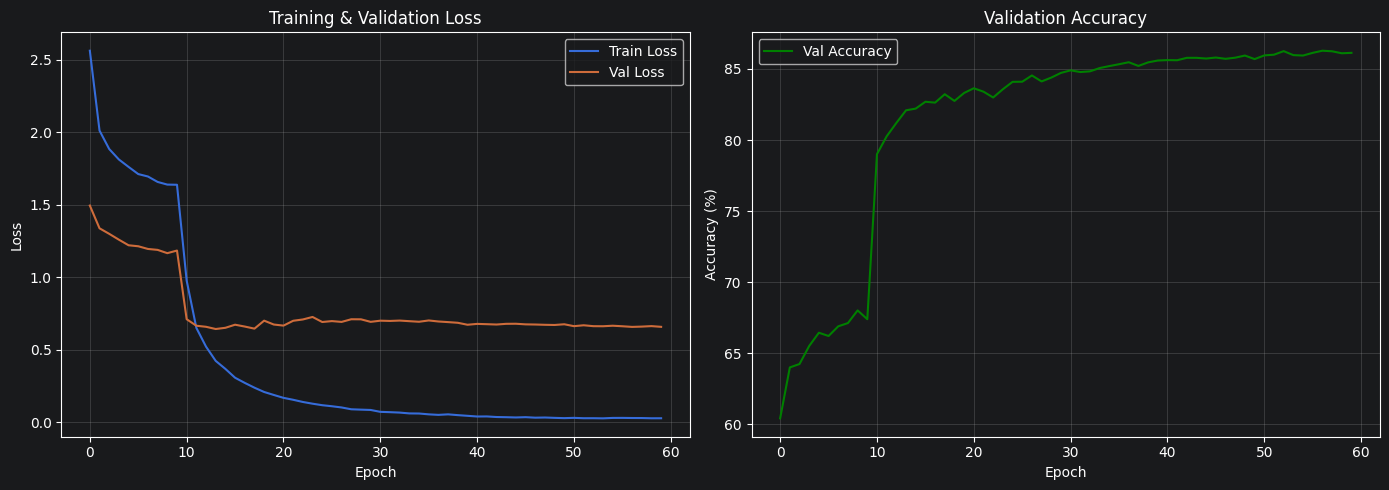

In [11]:
# Combine both phases for a single view
train_losses_all = train_losses_p1 + train_losses_p2
val_losses_all   = val_losses_p1   + val_losses_p2
val_accs_all     = val_accs_p1     + val_accs_p2

plot_training_curves(train_losses_all, val_losses_all, val_accs_all)

## Test Evaluation

Load the best checkpoint across **both phases** and evaluate.


In [12]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'Test Accuracy: {overall_acc:.2f}%\n')

print('Per-class accuracies (best first):')
sorted_classes = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
for cls, acc in sorted_classes:
    bar = '█' * int(acc / 5)
    print(f'  {cls:<20s} {acc:5.1f}%  {bar}')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet50_2phase_best.pth (score=86.2800)
Test Accuracy: 86.25%

Per-class accuracies (best first):
  skunk                 99.0%  ███████████████████
  motorcycle            98.0%  ███████████████████
  aquarium_fish         97.0%  ███████████████████
  orange                97.0%  ███████████████████
  sunflower             97.0%  ███████████████████
  tractor               97.0%  ███████████████████
  bicycle               96.0%  ███████████████████
  pickup_truck          96.0%  ███████████████████
  road                  96.0%  ███████████████████
  wardrobe              96.0%  ███████████████████
  chimpanzee            95.0%  ███████████████████
  skyscraper            95.0%  ███████████████████
  apple                 94.0%  ██████████████████
  keyboard              94.0%  ██████████████████
  lawn_mower            94.0%  ██████████████████
  tank                  94.0%  ██████████████████
  butterfly             93.0% 